# ***Start to Build Multi-Agent***

In [1]:
from dotenv import load_dotenv
import os
load_dotenv()
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [2]:
llm = ChatGroq(model=os.getenv("QWEN_MODEL"))
llm.invoke("test line")

AIMessage(content='<think>\nOkay, the user sent "test line". That\'s pretty short. I need to figure out what they\'re looking for. Maybe they just want to check if I\'m working. Let me respond in a friendly way. I should ask how I can assist them to get more context. Keep it open-ended so they can explain what they need help with. Make sure the tone is helpful and not too formal.\n</think>\n\nHello! It seems like you might be testing the waters. How can I assist you today? Feel free to ask any question or let me know if you need help with something specific! 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 126, 'prompt_tokens': 10, 'total_tokens': 136, 'completion_time': 0.287152435, 'prompt_time': 0.000364674, 'queue_time': 0.049908816999999994, 'total_time': 0.287517109}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_8487b76fd3', 'finish_reason': 'stop', 'logprobs': None}, id='run--704c934f-b988-46ad-815c-a2ed0ce6e5fb-0', usage_metadata={'

## **How command Function is Work**

In [3]:
from langgraph.types import Command
from langgraph.prebuilt import create_react_agent

In [4]:
def add_num(state):
    result = state["num1"] + state["num2"]
    print(f"addition is {result}")
    
    return Command(
        goto="multiply",
        update={
            "sum": result
        }
    )

In [5]:
state = {
    "num1": 5,
    "num2": 10
}
add_num(state=state)

addition is 15


Command(update={'sum': 15}, goto='multiply')

## **Creating a Dummy `Network Pattern` Agent**

In [39]:
from langchain.tools import tool

@tool
def transfer_to_multiplication_expert():
    """Ask multiplication agent for help"""
    return

In [40]:
@tool
def transfer_to_addition_expert():
    """Ask addition agent for help"""
    return

In [41]:
from typing import TypedDict, Sequence, Annotated, Literal
from langchain_core.messages import BaseMessage
from langgraph.graph import add_messages

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [42]:
llm_with_tools = llm.bind_tools([transfer_to_multiplication_expert])
response = llm_with_tools.invoke("Can you multiply 4 and 7!")
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '7srvv0q8m', 'function': {'arguments': '{}', 'name': 'transfer_to_multiplication_expert'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 260, 'prompt_tokens': 133, 'total_tokens': 393, 'completion_time': 0.503721754, 'prompt_time': 0.007700274, 'queue_time': 0.050272016, 'total_time': 0.511422028}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_8487b76fd3', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--5608ffb4-cfdc-4425-b94f-ca26e9d2e94c-0', tool_calls=[{'name': 'transfer_to_multiplication_expert', 'args': {}, 'id': '7srvv0q8m', 'type': 'tool_call'}], usage_metadata={'input_tokens': 133, 'output_tokens': 260, 'total_tokens': 393})

In [43]:
response.tool_calls[0]

{'name': 'transfer_to_multiplication_expert',
 'args': {},
 'id': '7srvv0q8m',
 'type': 'tool_call'}

In [44]:
from langgraph.graph import MessagesState, StateGraph, START, END

## **Agent-1**

In [ ]:
def addition_expert(state: MessagesState) -> Command[Literal["multiplication_expert", "__end__"]]:
    system_prompt = (
        "You are a addition expert, you can ask the multiplication expert for hep with multiplication."
        "Always do your portion of calculation before the handoff."
    )
    message = [
        {
            "role": "system",
            "content": system_prompt
        }
    ]
    messages = message + state["messages"]
    
    llm_with_tool = llm.bind_tools([transfer_to_multiplication_expert])
    response = llm_with_tool.invoke(messages)
    
    if len(response.tool_calls) > 0:
        tool_msg = {
                "role": "tool",
                "content": "Successfully Transferred",
                "tool_call_id": response.tool_calls[-1]["id"]
            }
        return Command(
            goto="multiplication_expert",
            update={
                "messages": [response, tool_msg]  
            }
        )
    print("hare-1")
    
    return {
        "messages": [response]
    }

## **Agent-2**

In [68]:
def multiplication_expert(state: MessagesState) -> Command[Literal["addition_expert", "__end__"]]:
    system_prompt = (
        "You are a Multiplication expert, you can ask the addition expert for hep with addition."
        "Always do your portion of calculation before the handoff."
    )
    message = [
        {
            "role": "system",
            "content": system_prompt
        }
    ]
    messages = message + state["messages"]
    
    llm_with_tool = llm.bind_tools([transfer_to_addition_expert])
    response = llm_with_tool.invoke(messages)
    
    if len(response.tool_calls) > 0:
        tool_msg = {
                "role": "tool",
                "content": "Successfully Transferred",
                "tool_call_id": response.tool_calls[-1]["id"]
            }
        return Command(
            goto="addition_expert",
            update={
                "messages": [response, tool_msg]  
            }
        )
    print("hare-2")
    return {
        "messages": [response]
    }

In [69]:
graph = StateGraph(MessagesState)

graph.add_node("addition_expert", addition_expert)
graph.add_node("multiplication_expert", multiplication_expert)

graph.add_edge(START, "addition_expert")

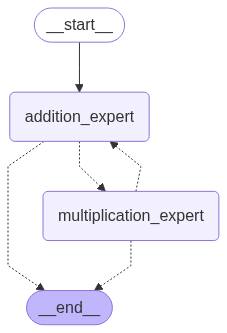

In [70]:
app = graph.compile()
app

In [71]:
output = app.invoke(
    {
        "messages": ["Can you add 2 and 4 and multiply with 7"]
    }
)

for m in output["messages"]:
    m.pretty_print()

hare-1
================================ Human Message =================================

Can you add 2 and 4 and multiply with 7
================================== Ai Message ==================================
Tool Calls:
  transfer_to_multiplication_expert (wdxyn92gp)
 Call ID: wdxyn92gp
  Args:
================================= Tool Message =================================

Successfully Transferred
================================== Ai Message ==================================
Tool Calls:
  transfer_to_addition_expert (bfhn0v3d4)
 Call ID: bfhn0v3d4
  Args:
================================= Tool Message =================================

Successfully Transferred
================================== Ai Message ==================================

The result of adding 2 and 4 is 6. Multiplying 6 by 7 gives **42**. 

Final answer: $\boxed{42}$


# **Build The Real Agents followed by `Network Pattern`**

In [72]:
## Search Tools
from langchain_tavily import TavilySearch
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

search_tool = TavilySearch(
    max_results=3,
    topic="general",
)


search_tool.invoke("capital of bangladesh!!")

{'query': 'capital of bangladesh!!',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': 'Dhaka - Simple English Wikipedia, the free encyclopedia',
   'url': 'https://simple.wikipedia.org/wiki/Dhaka',
   'content': 'Dhaka is the capital and largest city of Bangladesh. Dhaka is a megacity, and has a population of 10.2 million residents as of 2022, and a population of over 22.4 million residents in Greater Dhaka. [15][16][17] It is widely considered to be one of the most densely populated built-up urban area in the world. It is located just north of the Buriganga River, a channel of the Dhaleswari River, in',
   'score': 0.751375,
   'raw_content': None},
  {'title': 'Dhaka - Wikipedia',
   'url': 'https://en.wikipedia.org/wiki/Dhaka',
   'content': 'Dhaka became the capital of the Mughal province of Bengal, Bihar, and Orissa in 1610 with a jurisdiction covering modern-day Bangladesh and eastern India, including the modern-day Indian states of West Bengal

In [73]:
from langchain_experimental.utilities import PythonREPL
repl = PythonREPL()

code = """
x = 10
y = x + 4
print(y)
"""

repl.run(code)

Python REPL can execute arbitrary code. Use with caution.


'14\n'

In [76]:
@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."]
):
    """Use this to execute python code. if you want to see the output of a value, you should print it out `print(...). This is visible to the user"""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    
    result_str = f"Successfully executed: \n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    
    return (
        result_str + "\n\n if you have completed all tasks, respond with FINAL ANSWER"
    )

<>:11: SyntaxWarning: invalid escape sequence '\`'
<>:11: SyntaxWarning: invalid escape sequence '\`'
<>:11: SyntaxWarning: invalid escape sequence '\`'
<>:11: SyntaxWarning: invalid escape sequence '\`'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17440\2320112659.py:11: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed: \n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17440\2320112659.py:11: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed: \n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"


In [79]:
result = python_repl_tool.invoke(
    {
        "code": code
    }
)
print(result)

Successfully executed: 
\`\`\`python

x = 10
y = x + 4
print(y)

\`\`\`
Stdout: 14


 if you have completed all tasks, respond with FINAL ANSWER


In [80]:
## Agent-1
def research_node(state: MessagesState) -> Command[Literal["chart_generator", END]]:
    pass

In [ ]:
## Agent-2
def chart_node(state: MessagesState) -> Command[Literal["researcher", END]]:
    pass